# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** MEHTAB AHMED
**Student ID:** 023-24-0285
**Section:** H
**GitHub:*https://github.com/mehtabahmeddev/MACHINE-LEARNING/tree/ff06ab14e2610a61a9c1f8e4c7fc9764401562d1/Lab-07*
**Kaggle:*https://www.kaggle.com/mehtabahmed3201*
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [8]:
# Task 1 — load spam.csv, inspect shape/head/class balancedf
spam_df=pd.read_csv("spam.csv",encoding='ISO-8859-1')
spam_df.shape
spam_df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [9]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
tweets_df=pd.read_csv("Tweets.csv")
tweets_df.shape
tweets_df.head()
tweets_df['airline_sentiment'].value_counts()

neutral_rows = tweets_df[tweets_df['airline_sentiment'] == 'neutral'].index

tweets_df.drop(neutral_rows, inplace=True)
tweets_df['airline_sentiment'].value_counts()



airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64

**Answer 2 (Task A — spam):**
The problem is to identify whether an SMS message is spam or ham. It is a binary classification problem because there are only two classes: spam and ham.

**Answer 2 (Task B — sentiment):**
The problem is to identify whether a tweet has positive or negative sentiment. It is a binary classification problem because only two classes, positive and negative, are used.

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [12]:
# Task 3 — clean text
spam_df["clean_text"] = spam_df["v2"].str.lower()

spam_df[["v2", "clean_text"]].head()

,v2,clean_text
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


In [13]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets

spam_df["label_num"] = spam_df["v1"].map({
    "ham": 0,
    "spam": 1
})

X = spam_df["clean_text"]
y = spam_df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))


Vocabulary size: 7735


**Answer 4 (why fit on training data only):**
The vectorizer is fitted only on the training data so that it does not learn words from the test data. This prevents data leakage and gives a fair evaluation of the model.

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy: 0.9838565022421525
Precision: 0.9852941176470589
Recall: 0.8933333333333333
F1-score: 0.9370629370629371


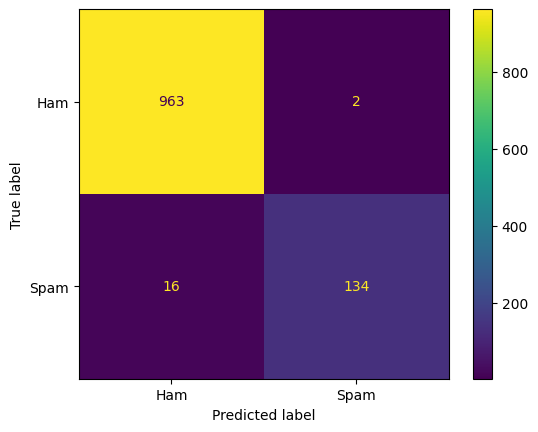

In [14]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix

model = MultinomialNB()

model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
).plot()

plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9838565022421525|
| Precision |0.9852941176470589 |
| Recall |0.8933333333333333 |
| F1-score |0.9370629370629371 |

**Answer 6:**
A false positive is worse in spam detection because it means a real and useful message is incorrectly classified as spam. This can cause the user to miss an important message, such as a university, work, or personal message. A false negative means that a spam message is allowed into the inbox, which is usually less serious than losing a real message. Therefore, if I were tuning the model further, I would prioritize precision because higher precision helps reduce the number of real messages incorrectly marked as spam.

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [15]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_

feature_names = vectorizer.get_feature_names_out()

top_ham = np.argsort(model.feature_log_prob_[0])[-15:][::-1]
top_spam = np.argsort(model.feature_log_prob_[1])[-15:][::-1]

print("Top 15 Ham Words:")
print(feature_names[top_ham])

print("\nTop 15 Spam Words:")
print(feature_names[top_spam])

Top 15 Ham Words:
['you' 'to' 'the' 'and' 'in' 'me' 'my' 'is' 'it' 'that' 'of' 'for' 'so'
 'have' 'but']

Top 15 Spam Words:
['to' 'call' 'you' 'your' 'free' 'for' 'the' 'now' 'or' 'txt' 'is' 'on'
 'ur' 'have' 'from']


**Answer 7:**
es, the words mostly match my intuition. Spam messages usually contain promotional or action-related words such as free, call, win, claim, or offer, while ham messages contain more normal conversational words.

In [19]:
# Task 8 — test your own messages
#my_messages = [
    # "your spam-like message here",
    # "your normal message here",]

# Task 8 — test your own messages

my_messages = [
    "Congratulations! You won a free prize, call now to claim it",
    "I love you?",
    "Free offer available now, text to claim your reward",
    "Hi Mehtab ,where are you attendnce is being marked"
]

clean_messages = [message.lower() for message in my_messages]

messages_vec = vectorizer.transform(clean_messages)

predictions = model.predict(messages_vec)

for message, prediction in zip(my_messages, predictions):
    print("Message:", message)

    if prediction == 1:
        print("Prediction: Spam")
    else:
        print("Prediction: Ham")

    print()


Message: Congratulations! You won a free prize, call now to claim it
Prediction: Spam

Message: I love you?
Prediction: Ham

Message: Free offer available now, text to claim your reward
Prediction: Spam

Message: Hi Mehtab ,where are you attendnce is being marked
Prediction: Ham



**Answer 8:**
es, the predictions match what I expected. The first and third messages look like spam because they contain prize and offer-related words, while the second and fourth message is a normal personal message and should be classified as ham

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
https://www.kaggle.com/code/mehtabahmed3201/notebook6dc46d7455


---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [20]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
# Task 11 — clean and vectorize the sentiment data

tweets_df["clean_text"] = tweets_df["text"].str.lower()

tweets_df["clean_text"] = tweets_df["clean_text"].str.replace(
    r"http\S+", "", regex=True
)

tweets_df["clean_text"] = tweets_df["clean_text"].str.replace(
    r"@\w+", "", regex=True
)

tweets_df["clean_text"] = tweets_df["clean_text"].str.replace(
    "#", "", regex=False
)

tweets_df["label_num"] = tweets_df["airline_sentiment"].map({
    "negative": 0,
    "positive": 1
})

X_tweet = tweets_df["clean_text"]
y_tweet = tweets_df["label_num"]

X_train_tweet, X_test_tweet, y_train_tweet, y_test_tweet = train_test_split(
    X_tweet,
    y_tweet,
    test_size=0.2,
    random_state=42
)

tweet_vectorizer = CountVectorizer()

X_train_tweet_vec = tweet_vectorizer.fit_transform(X_train_tweet)
X_test_tweet_vec = tweet_vectorizer.transform(X_test_tweet)

print("Vocabulary size:", len(tweet_vectorizer.get_feature_names_out()))

Vocabulary size: 10112


**Answer 12:**
I converted the tweets to lowercase and removed links and @mentions because they usually do not describe the actual sentiment of the tweet. I also removed the # symbol but kept the hashtag word because that word may still contain useful sentiment information.

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy: 0.9138155045474231
Precision: 0.9161073825503355
Recall: 0.610738255033557
F1-score: 0.7328859060402685


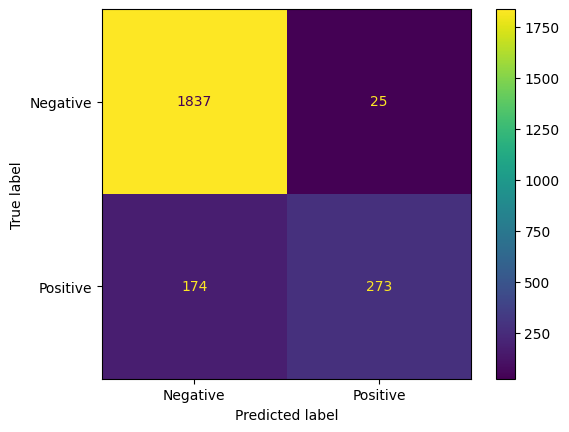

In [21]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix

sentiment_model = MultinomialNB()

sentiment_model.fit(X_train_tweet_vec, y_train_tweet)

y_pred_tweet = sentiment_model.predict(X_test_tweet_vec)

sentiment_accuracy = accuracy_score(y_test_tweet, y_pred_tweet)
sentiment_precision = precision_score(y_test_tweet, y_pred_tweet)
sentiment_recall = recall_score(y_test_tweet, y_pred_tweet)
sentiment_f1 = f1_score(y_test_tweet, y_pred_tweet)

print("Accuracy:", sentiment_accuracy)
print("Precision:", sentiment_precision)
print("Recall:", sentiment_recall)
print("F1-score:", sentiment_f1)

cm = confusion_matrix(y_test_tweet, y_pred_tweet)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
).plot()

plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.9138155045474231|
| Precision |0.9161073825503355|
| Recall |0.610738255033557 |
| F1-score |0.7328859060402685 |

**Answer 14:**
Naive Bayes performed better on spam detection than on sentiment classification. Task A achieved higher accuracy, precision, recall, and F1-score than Task B. Spam messages often contain clear individual words that strongly indicate spam, while tweet sentiment depends more on context and combinations of words. Therefore, the Naive Bayes assumption that words are independent is more reasonable for spam SMS than for tweets.

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
https://www.kaggle.com/code/mehtabahmed3201/notebook53c84ee35e

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.9839|0.9138|
| Precision |0.9853 |0.9138 |
| Recall |0.8933 |0.6107 |
| F1-score |0.9371 |0.7329 |

In [22]:
# Task 18 — train Logistic Regression on Task A's vectorized features
# Task 18 — Logistic Regression on Task A



lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_vec, y_train)

lr_pred = lr_model.predict(X_test_vec)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1-score:", lr_f1)


Accuracy: 0.9775784753363229
Precision: 0.9921259842519685
Recall: 0.84
F1-score: 0.9097472924187726


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | 0.9839|0.9776|
| Precision |0.9853|0.9921|
| Recall |0.8933|0.8400|
| F1-score |0.9371|0.9097 |

**Answer 18 (which wins, and does it match expectations):**
Naive Bayes performed better overall because it achieved higher accuracy, recall, and F1-score than Logistic Regression. Logistic Regression had slightly higher precision, but Naive Bayes gave the better overall balance between precision and recall. This matches my expectation because Naive Bayes often performs very well on text classification problems such as spam detection.

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
Naive Bayes performed better on the spam detection task than on the sentiment classification task. Spam messages often contain clear words that strongly indicate spam, while tweet sentiment depends more on context and combinations of words. I was surprised by how strongly a few simple words could help the model distinguish spam from ham. Naive Bayes also performed better overall than Logistic Regression on Task A because it achieved higher accuracy, recall, and F1-score. Logistic Regression only achieved slightly higher precision. One limitation I observed is that Naive Bayes treats words as independent, even though the meaning of a sentence often depends on how words are used together. This limitation was more noticeable in sentiment analysis, where context is very important.

**Answer 20 — Kaggle Notebook Links:**
- Task A: https://www.kaggle.com/code/mehtabahmed3201/notebook6dc46d7455
- Task B: https://www.kaggle.com/code/mehtabahmed3201/notebook53c84ee35e

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted